In [1]:
!pip install kagglehub

import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

dataset_path = path
print("Dataset Path:", dataset_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset Path: /kaggle/input/brain-tumor-mri-dataset


In [3]:
img_size = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 7200 files belonging to 2 classes.
Using 5760 files for training.
Found 7200 files belonging to 2 classes.
Using 1440 files for validation.
Classes: ['Testing', 'Training']


In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 729s 4s/step - accuracy: 0.7576 - loss: 15.7617 - val_accuracy: 0.7903 - val_loss: 0.5199
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 724s 4s/step - accuracy: 0.7773 - loss: 0.5170 - val_accuracy: 0.7861 - val_loss: 0.5265
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 686s 4s/step - accuracy: 0.7835 - loss: 0.4894 - val_accuracy: 0.7847 - val_loss: 0.5285
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 794s 4s/step - accuracy: 0.7896 - loss: 0.4659 - val_accuracy: 0.7701 - val_loss: 0.5601
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 707s 4s/step - accuracy: 0.7984 - loss: 0.4465 - val_accuracy: 0.7632 - val_loss: 0.5699
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 742s 4s/step - accuracy: 0.8108 - loss: 0.4168 - val_accuracy: 0.7812 - val_loss: 0.5954
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 701s 4s/step - accuracy: 0.8227 - loss: 0.4076 - val_accuracy: 0.7743 - val_loss: 0.6025
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 739s 4s/step - accuracy: 0.8325 - loss: 0.3826 - val_acc

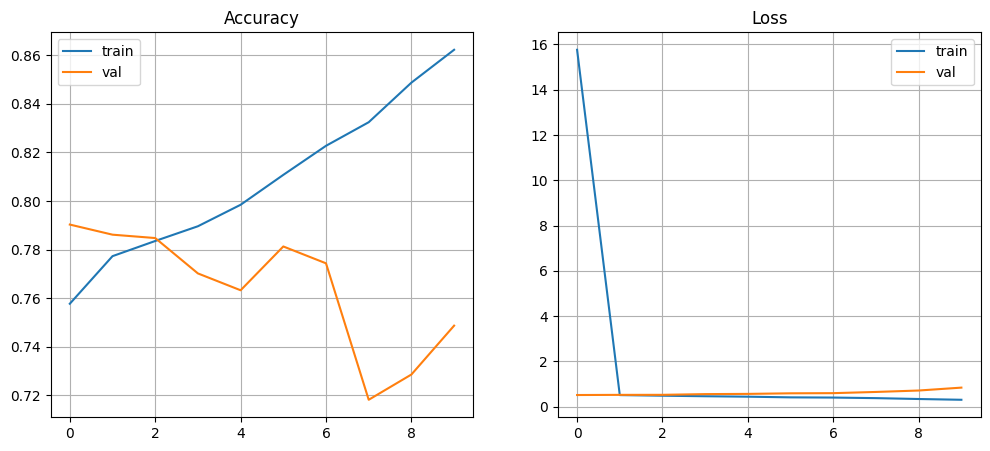

In [7]:
fig = plt.figure(figsize=(12, 5))

# Accuracy
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.legend()
ax1.grid()
ax1.set_title("Accuracy")

# Loss
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.legend()
ax2.grid()
ax2.set_title("Loss")

plt.show()

In [8]:
loss, accu = model.evaluate(val_ds, batch_size=batch_size)

print(f"Loss: {loss:.4f}, Accuracy: {accu*100:.2f}%")

45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7486 - loss: 0.8466
Loss: 0.8466, Accuracy: 74.86%
